# Comparative Analysis of Swarm and Evolutionary Metaheuristics
## Domain 1: The N-Queens Problem

This Section executes a comparative analysis between the Bat Algorithm (BA) and a Genetic Algorithm (GA) in solving the classic N Queens problem. Because queens must be placed on a rigid, discrete grid without attacking each other, this problem evaluates the algorithms  ability to navigate strict Integer Spaces.

### 1. Configurations
All hyperparameters are centralized here to allow for rapid experimental tuning without altering the underlying algorithmic architecture.

In [2]:
import math
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
# ---  GLOBAL EXPERIMENT SETTINGS ---
N_QUEENS = 8                # Size of the chessboard 
POPULATION_SIZE = 500       
MAX_GENERATIONS = 300       # Iterations for the main showdown     
             
# ---  BAT ALGORITHM HYPERPARAMETERS ---
BA_A0 = 0.9                  # Initial Loudness
BA_R0 = 0.1                 # Initial Pulse Rate
BA_FMIN = 0.5                # Minimum Frequency
BA_FMAX = 2.0                 # Maximum Frequency
# ---  GENETIC ALGORITHM HYPERPARAMETERS ---
GA_MUTATION_RATE = 0.3      # Probability of shifting a queen to a new row

# ---  ROBUSTNESS TEST SETTINGS ---
TEST_RUNS = 30              # Number of independent runs
TEST_POPULATION = 200       # Smaller population for faster multi-runs
TEST_GENERATIONS = 150      # Fewer generations for faster multi-runs

### 2. The Environment and Objective Function
The chessboard is represented as a 1D integer array where the *index* is the column and the *value* is the row. This inherently prevents vertical conflicts. 
The objective function is strict **Minimization**, calculating the total number of horizontal and diagonal attacking pairs. A perfect solution returns exactly `0` conflicts.

In [ ]:
#  THE OBJECTIVE FUNCTION 
def calculate_conflicts(board):
    """
    Calculates the number of attacking pairs of queens.
    Target fitness is exactly 0.
    """
    conflicts = 0
    n = len(board)
    for i in range(n):
        for j in range(i + 1, n):
            # Check horizontal conflict (same row)
            if board[i] == board[j]:
                conflicts += 1
            # Check diagonal conflict (distance between columns equals distance between rows)
            elif abs(board[i] - board[j]) == abs(i - j):
                conflicts += 1
    return conflicts


### 3. Discrete Math Engine (Continuous to Integer)
The native Bat Algorithm calculates velocity as continuous numbers (decimals). Because a queen cannot be placed on "Row 2.5", we must build a translation engine.
* **Continuous Tracker:** The bat flies through a decimal space using standard velocity equations.
* **Integer Snapping:** The continuous position is rounded and passed through a modulo (`% N`) operator to ensure the queen snaps to a valid integer coordinate within the board's boundaries.

In [4]:

def snap_to_integer(continuous_position, n):
    """
    Rounds a continuous position array to nearest integers and uses module 
    to ensure the queens wrap around if they fly off the edge of the board.
    """
    return [int(round(x)) % n for x in continuous_position]



### 4. The Bat Agent
The agent maintains a dual memory system: where it is continuous, and where the queen is physically placed (discrete). 
The Local Search phase or The Hunt phase, randomly moves a single queen to a new row, providing the abrupt disruption necessary to escape local minima trap.

In [5]:
# THE INTEGER BAT AGENT
class Bat_Agent:
    def __init__(self, n):
        # The physical board state
        self.discrete_position = [random.randint(0, n - 1) for _ in range(n)]
        # The mathematical coordinate tracker
        self.continuous_position = [float(x) for x in self.discrete_position]
        self.velocity = [0.0 for _ in range(n)]
        self.fitness = float('inf')
        self.A = BA_A0
        self.r = BA_R0
        self.r0 = BA_R0
        self.fmin = BA_FMIN
        self.fmax = BA_FMAX
        self.f = 0.0
        
    def update_frequency(self):
        self.f = self.fmin + (self.fmax - self.fmin) * random.random()

    def local_search(self, global_best_discrete):
        """The Huntis Teleport one queen to a completely new row."""
        new_discrete = global_best_discrete.copy()
        col_to_change = random.randint(0, len(new_discrete) - 1)
        new_discrete[col_to_change] = random.randint(0, len(new_discrete) - 1)
        return new_discrete
        
    def update_parameters(self, iteration, alpha=0.9, gamma=0.05):
        self.A = alpha * self.A
        self.r = self.r0 * (1 - math.exp(-gamma * iteration))

### 5. Bat Algorithm Execution
The swarm navigates the integer space. The acceptance criteria strictly requires the new board state to have fewer or equal (`<=`) conflicts than the current state, while checking if the bat's loudness (`A`) permits the update.

In [6]:
# BA Execution
def ba_nqueens(n, num_bats, max_iterations):
    swarm = [Bat_Agent(n) for _ in range(num_bats)]
    
    global_best_position = None
    global_best_fitness = float('inf')
    logbook = []
    
    for bat in swarm:
        bat.fitness = calculate_conflicts(bat.discrete_position)
        if bat.fitness < global_best_fitness:
            global_best_fitness = bat.fitness
            global_best_position = bat.discrete_position.copy()
            
    for t in range(max_iterations):
        gen_start_time = time.time()
        current_swarm_fitness = []
        
        for bat in swarm:
            bat.update_frequency()
            
            # Flight Math
            for j in range(n):
                bat.velocity[j] += (global_best_position[j] - bat.continuous_position[j]) * bat.f
                bat.continuous_position[j] += bat.velocity[j]
                
            # Snap to valid board state
            new_discrete = snap_to_integer(bat.continuous_position, n)
            
            # Hunt!
            if random.random() > bat.r:
                new_discrete = bat.local_search(global_best_position)
                
            new_fitness = calculate_conflicts(new_discrete)
            
            # Acceptance Part (0 conflicts is the goal)
            if new_fitness <= bat.fitness and random.random() < bat.A:
                bat.discrete_position = new_discrete.copy()
                bat.continuous_position = [float(x) for x in new_discrete]
                bat.fitness = new_fitness
                bat.update_parameters(t)
                
            if bat.fitness < global_best_fitness:
                global_best_fitness = bat.fitness
                global_best_position = bat.discrete_position.copy()
                
            current_swarm_fitness.append(bat.fitness)

        gen_exec_time = time.time() - gen_start_time
        current_avg = sum(current_swarm_fitness) / num_bats
        
        logbook.append({
            "gen": t,
            "nevals": num_bats,
            "exec_time_seconds": round(gen_exec_time, 6),
            "min": global_best_fitness,
            "avg": round(current_avg, 3)
        })
        
        if global_best_fitness == 0: 
            break # Early exit if perfect board found

    return global_best_position, global_best_fitness, pd.DataFrame(logbook)

### 6. Genetic Algorithm Baseline
The control group utilizes standard evolutionary operators adapted for integer arrays:
* **Single Point Crossover:** Slices two parent boards and combines them to pass down safe formations.
* **Integer Mutation:** Randomly shifts a single queen to a new row to maintain genetic diversity and break out of 1-conflict traps.

In [7]:
# INTEGER GENETIC ALGORITHM
def ga_nqueen(n, pop_size, max_iterations):
    population = [[random.randint(0, n - 1) for _ in range(n)] for _ in range(pop_size)]
    
    global_best_position = None
    global_best_fitness = float('inf')
    logbook = []

    for t in range(max_iterations):
        gen_start_time = time.time()
        
        pop_fitness = [(ind, calculate_conflicts(ind)) for ind in population]
        pop_fitness.sort(key=lambda x: x[1]) # Ascending order (lowest conflicts first)
        
        current_min = pop_fitness[0][1]
        current_avg = sum(f for _, f in pop_fitness) / pop_size
        
        if current_min < global_best_fitness:
            global_best_fitness = current_min
            global_best_position = pop_fitness[0][0].copy()
            
        next_gen = [pop_fitness[0][0], pop_fitness[1][0]] # Elitism
        
        while len(next_gen) < pop_size:
            p1 = min(random.sample(pop_fitness, 3), key=lambda x: x[1])[0]
            p2 = min(random.sample(pop_fitness, 3), key=lambda x: x[1])[0]
            
            # Single-Point Crossover
            crossover_point = random.randint(1, n - 2)
            child = p1[:crossover_point] + p2[crossover_point:]
            
            # Mutation
            if random.random() < GA_MUTATION_RATE:
                col_to_mutate = random.randint(0, n - 1)
                child[col_to_mutate] = random.randint(0, n - 1)
                
            next_gen.append(child)
            
        population = next_gen
        gen_exec_time = time.time() - gen_start_time
        
        logbook.append({
            "gen": t,
            "nevals": pop_size,
            "exec_time_seconds": round(gen_exec_time, 6),
            "min": current_min,
            "avg": round(current_avg, 3)
        })
        
        if current_min == 0:
            break

    return global_best_position, global_best_fitness, pd.DataFrame(logbook)

### 7. Statistical Showdown and Chessboard Visualization
Both algorithms are executed under identical population constraints. The outcomes are compared via execution time, convergence speed, and a direct visual rendering of the final physical chessboard states.

Run on 8-Queens (Pop: 500, Gen: 300)...

  BAT ALGORITHM RESULTS==
0 - Best conflicts: 1 - Avg Conflicts: 3.4500 - Time: 0.0081s
1 - Best conflicts: 1 - Avg Conflicts: 2.4180 - Time: 0.0080s
2 - Best conflicts: 1 - Avg Conflicts: 2.0240 - Time: 0.0075s
3 - Best conflicts: 1 - Avg Conflicts: 1.8360 - Time: 0.0076s
4 - Best conflicts: 1 - Avg Conflicts: 1.6780 - Time: 0.0070s
5 - Best conflicts: 1 - Avg Conflicts: 1.5640 - Time: 0.0060s
6 - Best conflicts: 1 - Avg Conflicts: 1.4800 - Time: 0.0080s
7 - Best conflicts: 1 - Avg Conflicts: 1.4060 - Time: 0.0060s
8 - Best conflicts: 1 - Avg Conflicts: 1.3620 - Time: 0.0080s
9 - Best conflicts: 1 - Avg Conflicts: 1.3240 - Time: 0.0070s
10 - Best conflicts: 1 - Avg Conflicts: 1.2880 - Time: 0.0066s
11 - Best conflicts: 1 - Avg Conflicts: 1.2580 - Time: 0.0070s
12 - Best conflicts: 1 - Avg Conflicts: 1.2360 - Time: 0.0060s
13 - Best conflicts: 1 - Avg Conflicts: 1.2200 - Time: 0.0071s
14 - Best conflicts: 1 - Avg Conflicts: 1.1880 - Time: 0.0070

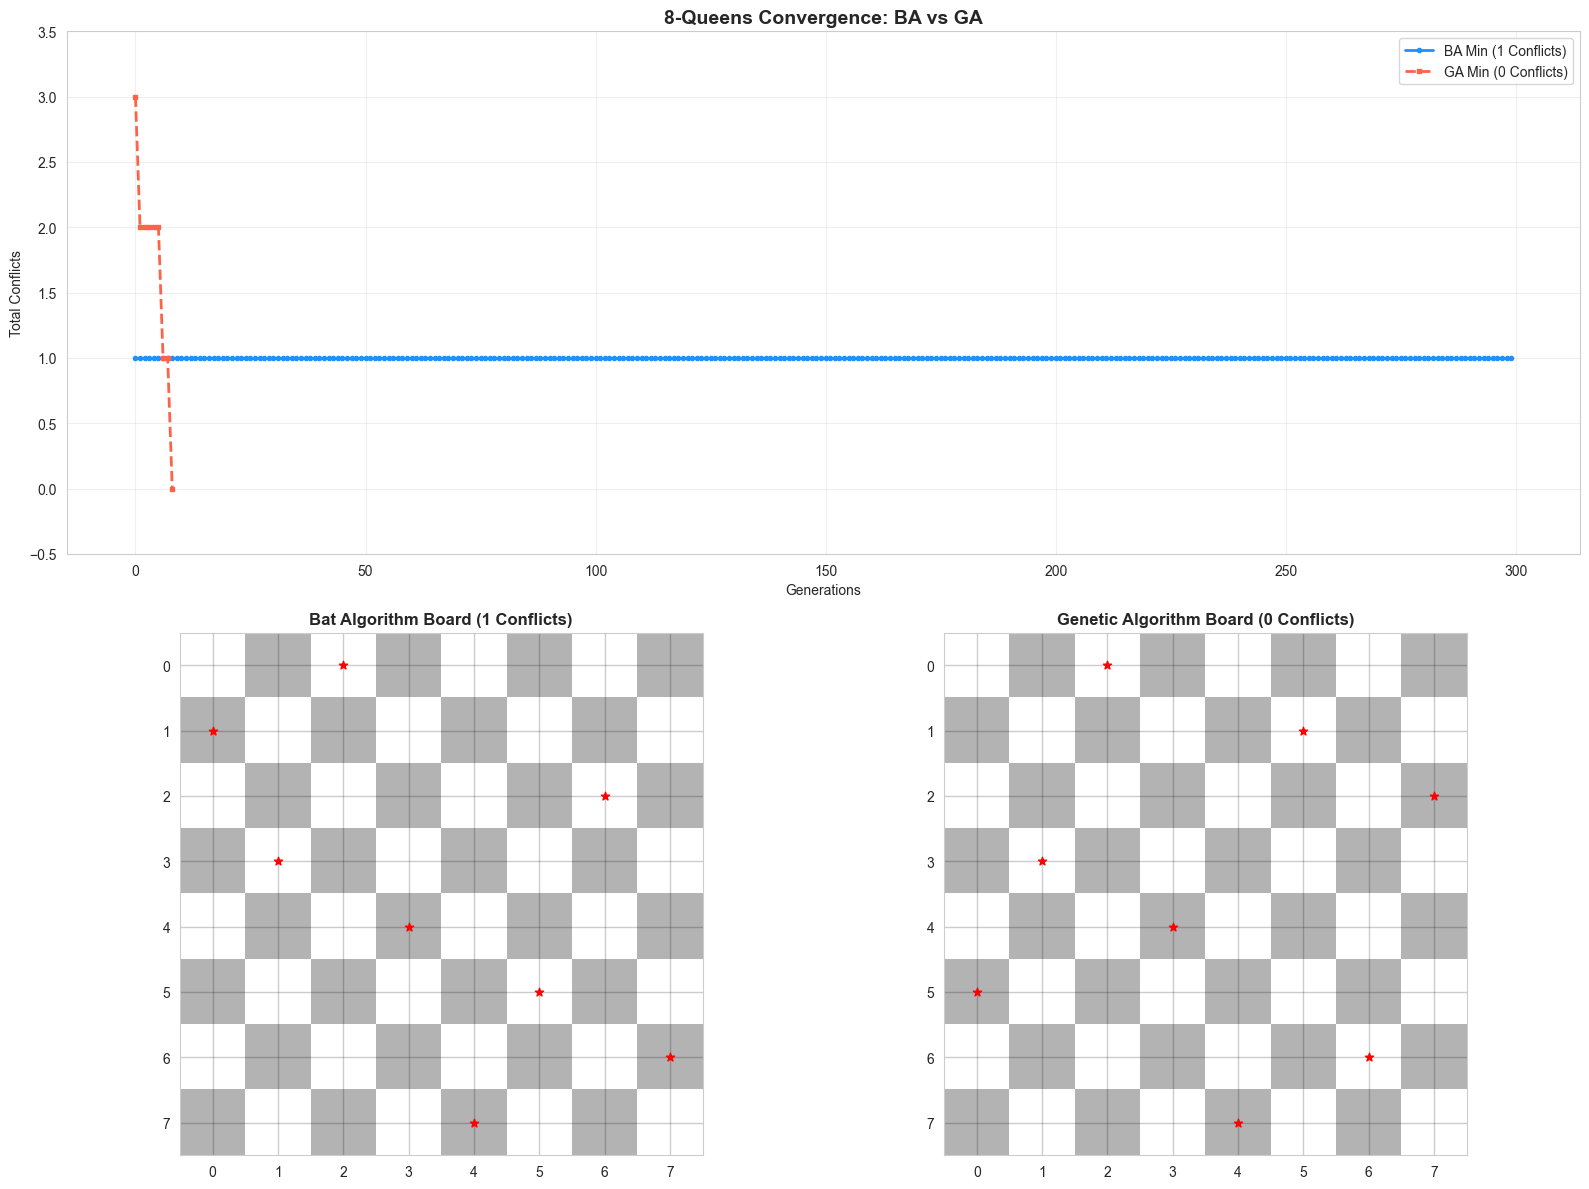

In [8]:
#  NQUEENS Run
print(f"Run on {N_QUEENS}-Queens (Pop: {POPULATION_SIZE}, Gen: {MAX_GENERATIONS})...\n")

ba_pos, ba_fit, ba_log = ba_nqueens(N_QUEENS, POPULATION_SIZE, MAX_GENERATIONS)
ga_pos, ga_fit, ga_log = ga_nqueen(N_QUEENS, POPULATION_SIZE, MAX_GENERATIONS)

print("  BAT ALGORITHM RESULTS==")
for index, row in ba_log.head(15).iterrows():
    print(f"{int(row['gen'])} - Best conflicts: {int(row['min'])} - Avg Conflicts: {row['avg']:.4f} - Time: {row['exec_time_seconds']:.4f}s")
print(f"\nBest solution:\n0 :  {float(ba_fit)}  ->  Individual('i', {ba_pos})\n")

print("GENETIC ALGORITHM RESULTS==")
for index, row in ga_log.head(15).iterrows():
    print(f"{int(row['gen'])} - Best conflicts: {int(row['min'])} - Avg Conflicts: {row['avg']:.4f} - Time: {row['exec_time_seconds']:.4f}s")
print(f"\nBest solution:\n0 :  {float(ga_fit)}  ->  Individual('i', {ga_pos})\n\n")

# --- Sumary Table ---
table_data = [
    ["Algorithm", "Population", "Gens Executed", "Final Conflicts", "Final Avg Conflicts", "Total Time (s)", "Avg Gen Time (s)"],
    ["Bat Algorithm", POPULATION_SIZE, len(ba_log), ba_fit, f"{ba_log['avg'].iloc[-1]:.3f}", f"{ba_log['exec_time_seconds'].sum():.4f}", f"{ba_log['exec_time_seconds'].mean():.6f}"],
    ["Genetic Algorithm", POPULATION_SIZE, len(ga_log), ga_fit, f"{ga_log['avg'].iloc[-1]:.3f}", f"{ga_log['exec_time_seconds'].sum():.4f}", f"{ga_log['exec_time_seconds'].mean():.6f}"]
]
print("--- Alg PERFORMANCE SUMMARY ---")
print(tabulate(table_data, headers='firstrow', tablefmt='fancy_grid'))
print("\n")

#Charts 

sns.set_style("whitegrid")
fig = plt.figure(figsize=(16, 12))

# Convergence Plot 
ax1 = plt.subplot(2, 1, 1)

# Use actual generation ranges from logs
ba_gens = ba_log['gen'].values
ga_gens = ga_log['gen'].values

ax1.plot(ba_gens, ba_log['min'], color='dodgerblue', linewidth=2, 
         label=f'BA Min ({ba_fit} Conflicts)', marker='o', markersize=3)
ax1.plot(ga_gens, ga_log['min'], color='tomato', linestyle='--', linewidth=2, 
         label=f'GA Min ({ga_fit} Conflicts)', marker='s', markersize=3)

ax1.set_title(f"{N_QUEENS}-Queens Convergence: BA vs GA", fontsize=14, fontweight='bold')
ax1.set_xlabel("Generations")
ax1.set_ylabel("Total Conflicts")
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.5, max(ba_log['min'].max(), ga_log['min'].max()) + 0.5)


#Chessboards
def plot_chessboard(ax, position, title):
    n = len(position)
    board = np.zeros((n, n))
    board[1::2, ::2] = 1
    board[::2, 1::2] = 1
    ax.imshow(board, cmap='gray_r', alpha=0.3)
    ax.set_aspect('equal') 
    # Shrink stars as N increases
    star_size = max(15, 300 / n)  
    for col, row in enumerate(position):
        ax.scatter(col, row, color='red', s=star_size, marker='*')
        
    ax.set_title(title, fontweight='bold')
    #Prevent number overlap on large axes
    tick_step = 2 if n >= 16 else 1
    ax.set_xticks(range(0, n, tick_step))
    ax.set_yticks(range(0, n, tick_step))
    
    ax.grid(color='black', linestyle='-', linewidth=1, alpha=0.2)

ax2 = plt.subplot(2, 2, 3)
plot_chessboard(ax2, ba_pos, f"Bat Algorithm Board ({ba_fit} Conflicts)")
ax3 = plt.subplot(2, 2, 4)
plot_chessboard(ax3, ga_pos, f"Genetic Algorithm Board ({ga_fit} Conflicts)")

plt.tight_layout()
plt.show()

### 8. Stochastic Robustness Test
Because N-Queens is highly deceptive (a board with 1 conflict might be structurally further from a perfect solution than a board with 3 conflicts), a single execution is statistically insufficient. This cell executes 10 independent runs of both algorithms to evaluate their variance, reliability, and success rate in reaching exactly `0`.

In [9]:

print(f"--- ROBUSTNESS TEST ({TEST_RUNS}  Runs) ---")

ba_final_conflicts, ga_final_conflicts = [], []
ba_logs_all, ga_logs_all = [], []  #Store full logs here
ba_success_gen, ga_success_gen = [], [] #Store which gen they solved it (or -1)

for i in range(TEST_RUNS):
    print(f"Executing run {i+1}/{TEST_RUNS}... ", end="")
    
    # Run BA
    _, ba_fit, ba_log = ba_nqueens(N_QUEENS, TEST_POPULATION, TEST_GENERATIONS)
    ba_final_conflicts.append(ba_fit)
    ba_logs_all.append(ba_log)
    ba_success_gen.append(ba_log[ba_log['min'] == 0]['gen'].min() if any(ba_log['min'] == 0) else -1)

    # Run GA
    _, ga_fit, ga_log = ga_nqueen(N_QUEENS, TEST_POPULATION, TEST_GENERATIONS)
    ga_final_conflicts.append(ga_fit)
    ga_logs_all.append(ga_log)
    ga_success_gen.append(ga_log[ga_log['min'] == 0]['gen'].min() if any(ga_log['min'] == 0) else -1)
    
    print("done")

print("\nProcessing statistics...\n")
ba_success = (ba_final_conflicts.count(0) / TEST_RUNS) * 100
ga_success = (ga_final_conflicts.count(0) / TEST_RUNS) * 100

table_data = [
    ["Algorithm", "Best Run", "Worst Run", "Average Conflicts", "Std Deviation", "Hit Rate (0)"],
    ["Bat Algorithm", np.min(ba_final_conflicts), np.max(ba_final_conflicts), f"{np.mean(ba_final_conflicts):.2f}", f"{np.std(ba_final_conflicts):.2f}", f"{ba_success}%"],
    ["Genetic Algorithm", np.min(ga_final_conflicts), np.max(ga_final_conflicts), f"{np.mean(ga_final_conflicts):.2f}", f"{np.std(ga_final_conflicts):.2f}", f"{ga_success}%"]
]
print(tabulate(table_data, headers='firstrow', tablefmt='fancy_grid'))
 

--- ROBUSTNESS TEST (30  Runs) ---
Executing run 1/30... done
Executing run 2/30... done
Executing run 3/30... done
Executing run 4/30... done
Executing run 5/30... done
Executing run 6/30... done
Executing run 7/30... done
Executing run 8/30... done
Executing run 9/30... done
Executing run 10/30... done
Executing run 11/30... done
Executing run 12/30... done
Executing run 13/30... done
Executing run 14/30... done
Executing run 15/30... done
Executing run 16/30... done
Executing run 17/30... done
Executing run 18/30... done
Executing run 19/30... done
Executing run 20/30... done
Executing run 21/30... done
Executing run 22/30... done
Executing run 23/30... done
Executing run 24/30... done
Executing run 25/30... done
Executing run 26/30... done
Executing run 27/30... done
Executing run 28/30... done
Executing run 29/30... done
Executing run 30/30... done

Processing statistics...

╒═══════════════════╤════════════╤═════════════╤═════════════════════╤═════════════════╤═══════════════════

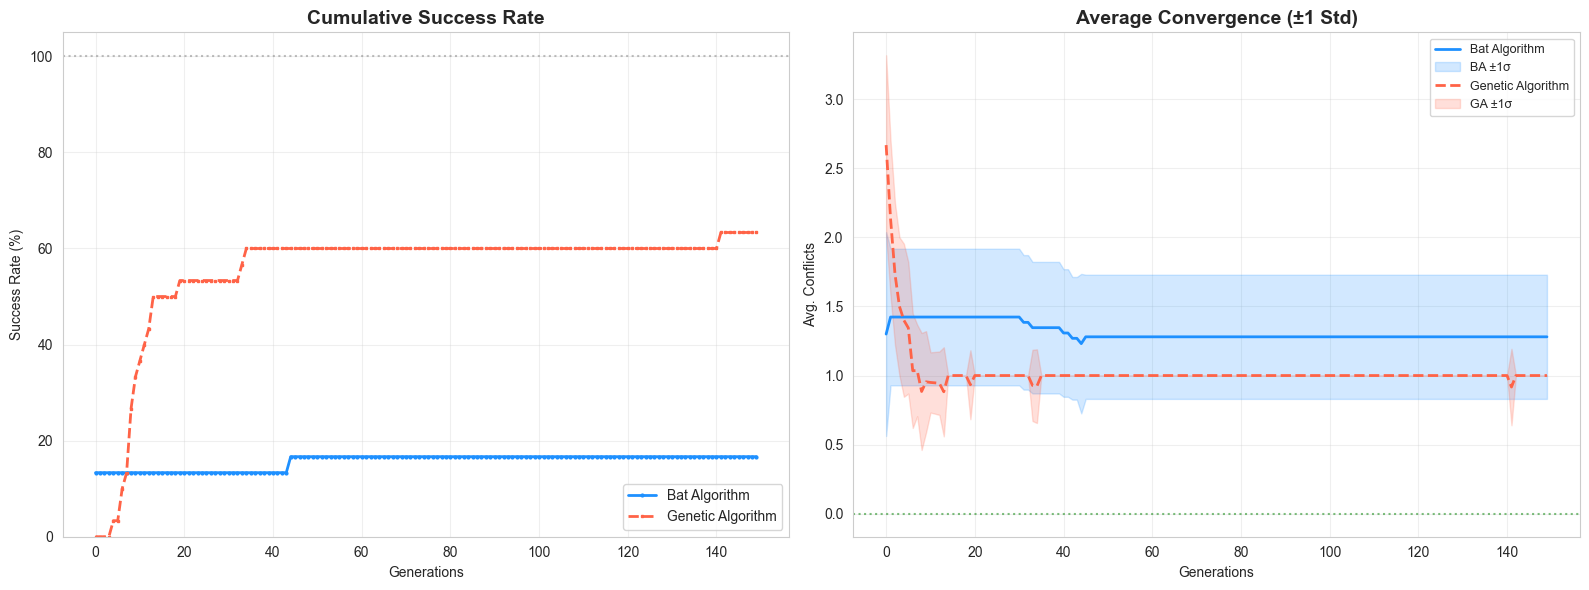

In [10]:
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#Cumulative Success Rate 
max_gen = TEST_GENERATIONS
generations = range(max_gen)

ba_success_rates = []
ga_success_rates = []

for t in generations:
    ba_solved = sum(1 for log in ba_logs_all 
                   if not log.empty and (log.loc[log['gen'] <= t, 'min'].min() == 0 
                                         if not log[log['gen'] <= t].empty else False))
    ga_solved = sum(1 for log in ga_logs_all 
                   if not log.empty and (log.loc[log['gen'] <= t, 'min'].min() == 0 
                                         if not log[log['gen'] <= t].empty else False))
    
    ba_success_rates.append((ba_solved / TEST_RUNS) * 100)
    ga_success_rates.append((ga_solved / TEST_RUNS) * 100)

ax1.plot(generations, ba_success_rates, label='Bat Algorithm', 
         color='dodgerblue', linewidth=2, marker='o', markersize=2)
ax1.plot(generations, ga_success_rates, label='Genetic Algorithm', 
         color='tomato', linewidth=2, linestyle='--', marker='s', markersize=2)

ax1.set_title("Cumulative Success Rate", fontsize=14, fontweight='bold')
ax1.set_xlabel("Generations")
ax1.set_ylabel("Success Rate (%)")
ax1.legend(loc='lower right')
ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=100, color='gray', linestyle=':', alpha=0.5)

#Chart 2: Average Convergence with Std Dev
ba_avg_min, ba_std_min = [], []
ga_avg_min, ga_std_min = [], []

for t in range(max_gen):
    ba_vals = [log.loc[log['gen'] == t, 'min'].values[0] 
               if not log[log['gen'] == t].empty else np.nan 
               for log in ba_logs_all]
    ga_vals = [log.loc[log['gen'] == t, 'min'].values[0] 
               if not log[log['gen'] == t].empty else np.nan 
               for log in ga_logs_all]
    
    ba_avg_min.append(np.nanmean(ba_vals))
    ba_std_min.append(np.nanstd(ba_vals))
    ga_avg_min.append(np.nanmean(ga_vals))
    ga_std_min.append(np.nanstd(ga_vals))

ax2.plot(range(max_gen), ba_avg_min, label='Bat Algorithm', 
         color='dodgerblue', linewidth=2)
ax2.fill_between(range(max_gen), 
                 np.array(ba_avg_min) - np.array(ba_std_min), 
                 np.array(ba_avg_min) + np.array(ba_std_min), 
                 color='dodgerblue', alpha=0.2, label='BA ±1σ')

ax2.plot(range(max_gen), ga_avg_min, label='Genetic Algorithm', 
         color='tomato', linestyle='--', linewidth=2)
ax2.fill_between(range(max_gen), 
                 np.array(ga_avg_min) - np.array(ga_std_min), 
                 np.array(ga_avg_min) + np.array(ga_std_min), 
                 color='tomato', alpha=0.2, label='GA ±1σ')

ax2.set_title("Average Convergence (±1 Std)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Generations")
ax2.set_ylabel("Avg. Conflicts")
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='green', linestyle=':', alpha=0.5, label='Optimal (0 conflicts)')

plt.tight_layout()
plt.savefig('ba_vs_ga_advanced.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\parsa\AppData\Local\Temp\ipykernel_1148\672595499.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
C:\Users\parsa\AppData\Local\Temp\ipykernel_1148\672595499.py:79: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\parsa\AppData\Local\Temp\ipykernel_1148\672595499.py:80: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('ba_vs_ga_statistics.png', dpi=300, bbox_inches='tight')
f:\Bat_Colony_opt\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


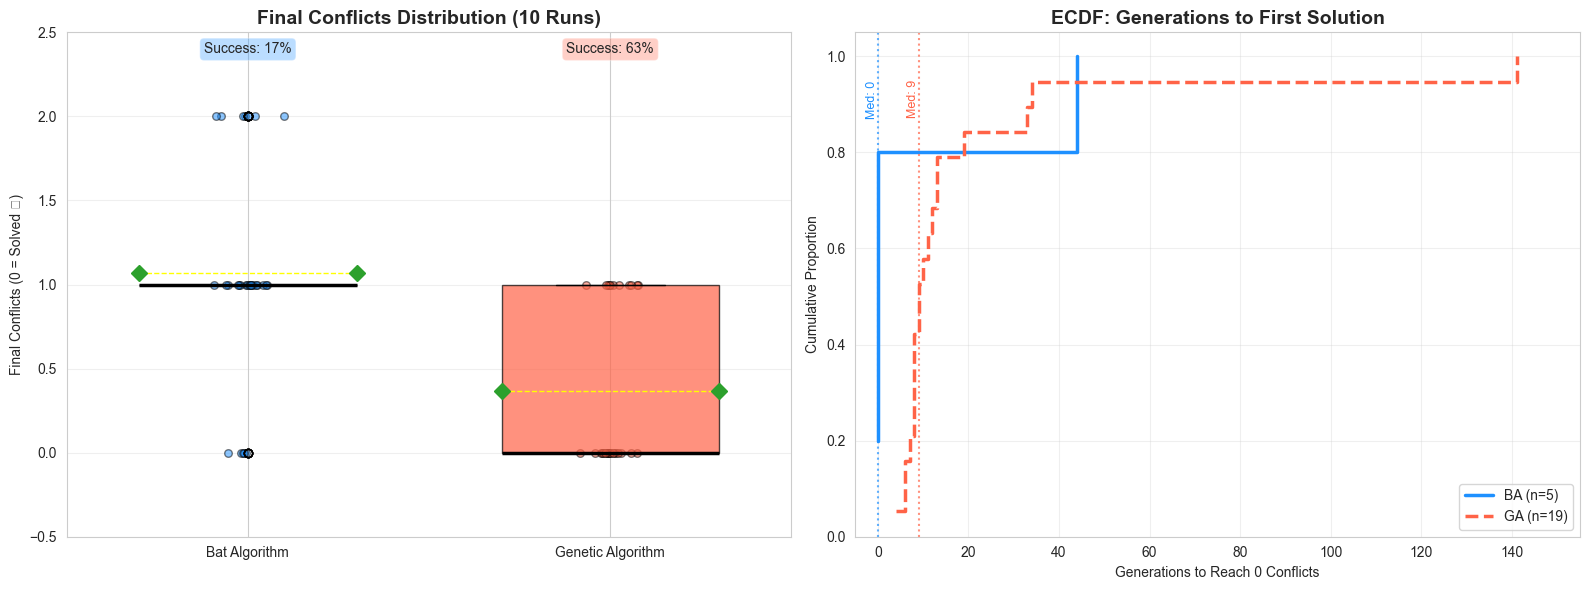


 Stat Summary
BA - Median gens : 0.0
BA - Mean gens : 8.8 ± 17.6
GA - Median gens : 9.0
GA - Mean gens: 18.9 ± 29.9

Mann Whitney U test: p=0.038 [Significant]


In [11]:
from scipy import stats

sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#Boxplot of Final Conflicts 
data = [ba_final_conflicts, ga_final_conflicts]
labels = ['Bat Algorithm', 'Genetic Algorithm']
colors = ['dodgerblue', 'tomato']

bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.6, 
                 notch=False, showmeans=True, meanline=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set(color='black', linewidth=2.5)
for mean in bp['means']:
    mean.set(color='yellow', marker='D', markersize=8, label='Mean')

for i, conflicts in enumerate(data, 1):
    y = np.random.normal(i, 0.04, size=len(conflicts))
    ax1.scatter(y, conflicts, alpha=0.5, color=colors[i-1], s=30, edgecolors='black')

ax1.set_title("Final Conflicts Distribution (10 Runs)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Final Conflicts (0 = Solved ✓)")
ax1.set_ylim(-0.5, max(max(ba_final_conflicts), max(ga_final_conflicts), 2) + 0.5)
ax1.grid(True, alpha=0.3, axis='y')

# Add success rate text
ba_success = ba_final_conflicts.count(0) / TEST_RUNS * 100
ga_success = ga_final_conflicts.count(0) / TEST_RUNS * 100
ax1.text(1, ax1.get_ylim()[1]*0.95, f'Success: {ba_success:.0f}%', 
         ha='center', bbox=dict(boxstyle='round', facecolor='dodgerblue', alpha=0.3))
ax1.text(2, ax1.get_ylim()[1]*0.95, f'Success: {ga_success:.0f}%', 
         ha='center', bbox=dict(boxstyle='round', facecolor='tomato', alpha=0.3))

ba_solved_gens = [g for g in ba_success_gen if g != -1]
ga_solved_gens = [g for g in ga_success_gen if g != -1]

def compute_ecdf(data):
    if len(data) == 0:
        return np.array([]), np.array([])
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x_ba, y_ba = compute_ecdf(ba_solved_gens)
x_ga, y_ga = compute_ecdf(ga_solved_gens)

if len(x_ba) > 0:
    ax2.step(x_ba, y_ba, label=f'BA (n={len(ba_solved_gens)})', 
             color='dodgerblue', linewidth=2.5, where='post')
if len(x_ga) > 0:
    ax2.step(x_ga, y_ga, label=f'GA (n={len(ga_solved_gens)})', 
             color='tomato', linewidth=2.5, linestyle='--', where='post')

# Add median lines
if len(ba_solved_gens) > 0:
    med_ba = np.median(ba_solved_gens)
    ax2.axvline(med_ba, color='dodgerblue', linestyle=':', alpha=0.7)
    ax2.text(med_ba, 0.95, f'Med: {med_ba:.0f}', color='dodgerblue', 
             ha='right', va='top', fontsize=9, rotation=90)
if len(ga_solved_gens) > 0:
    med_ga = np.median(ga_solved_gens)
    ax2.axvline(med_ga, color='tomato', linestyle=':', alpha=0.7)
    ax2.text(med_ga, 0.95, f'Med: {med_ga:.0f}', color='tomato', 
             ha='right', va='top', fontsize=9, rotation=90)

ax2.set_title("ECDF: Generations to First Solution", fontsize=14, fontweight='bold')
ax2.set_xlabel("Generations to Reach 0 Conflicts")
ax2.set_ylabel("Cumulative Proportion")
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-5, TEST_GENERATIONS + 5)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('ba_vs_ga_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Stat Summary")
print("="*50)
if ba_solved_gens:
    print(f"BA - Median gens : {np.median(ba_solved_gens):.1f}")
    print(f"BA - Mean gens : {np.mean(ba_solved_gens):.1f} ± {np.std(ba_solved_gens):.1f}")
if ga_solved_gens:
    print(f"GA - Median gens : {np.median(ga_solved_gens):.1f}")
    print(f"GA - Mean gens: {np.mean(ga_solved_gens):.1f} ± {np.std(ga_solved_gens):.1f}")

if len(ba_solved_gens) >= 3 and len(ga_solved_gens) >= 3:
    stat, pval = stats.mannwhitneyu(ba_solved_gens, ga_solved_gens, alternative='two-sided')
    sig = "Significant" if pval < 0.05 else "Not significant"
    print(f"\nMann Whitney U test: p={pval:.3f} [{sig}]")